# 09.1 — Does curvature change a global linear probe's local R²? A Swiss roll check

Phase 9 measured the association between local curvature and the local out-of-fold R² of one
global ridge probe, and got opposite signs under two curvature estimators. Nothing in the record
ran that pipeline on a surface where curvature, tangent planes, density and the label are all
known. This notebook does, on the Swiss roll.

Three label arms, same points, same sealed pipeline (`physics_curvature_probe`): OOF ridge
probe at `alpha = 100`, `k`-neighbourhood local R², the three controls, the controlled partial
Spearman and its Freedman-Lane null.

- **`y = h`** (height): linear in ambient space. Run twice: at the frozen `alpha = 100`, and at
  `alpha ≈ 0` (ordinary least squares). With no shrinkage the probe fits `h` exactly, local R² is
  ≈ 1 everywhere and the curvature partial must be ≈ 0. The `alpha = 100` copy shows what ridge
  shrinkage alone does to the statistic on a curved, non-uniformly sampled surface. Null arms.
- **`y = t`** (arc parameter): linear in intrinsic coordinates, wraps in ambient space. A global
  linear map must fail somewhere. Main arm.
- **`y = sin(t/2) + (h/h_max)²`**: smooth and nonlinear in both coordinates.

Beside the exact curvature `||H||` we compute one more exact quantity per anchor: the cosine
between the probe's weight vector projected onto the tangent plane and the label's own
gradient on the surface. That is the mechanism by which a fixed linear map can succeed or fail
on a curved surface. The question is whether local R² follows `||H||` or follows that
alignment. No cache, no pre-registration; seconds to run.

## §1. Setup

In [1]:
import sys
from pathlib import Path

NOTEBOOK_DIR = Path.cwd()
if str(NOTEBOOK_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOK_DIR))

import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import spearmanr
from sklearn.datasets import make_swiss_roll
from sklearn.linear_model import Ridge

from pu_manifold import curvature_probe
from pu_manifold import physics_curvature_probe as pcp

SEED = 0
N_POINTS = 3000
K = 256                 # largest preset <= n/8, the colleague's own rule at this n
N_ANCHORS = 256
N_PERMUTATIONS = 5000
print(f"numpy {np.__version__}; alpha={pcp.ALPHA_RIDGE}, folds={pcp.N_OOF_FOLDS}, controls={pcp.CONTROLS}")

numpy 2.5.1; alpha=100.0, folds=5, controls=('log_knn_radius', 'local_label_variance', 'local_evaluation_count')


## §2. The Swiss roll, with everything known

`make_swiss_roll` parametrises `X(t, h) = (t cos t, h, t sin t)`. Centre and divide by one
global standard deviation. The sealed analytic curvature `kappa(t) = (t² + 2)/(1 + t²)^1.5`
(trace convention) falls outward. The tangent plane is spanned by `∂_t = (cos t − t sin t, 0,
sin t + t cos t)` and `∂_h = (0, 1, 0)`. Uniform `t` gives sampling density proportional to
`1/||∂_t|| = 1/sqrt(1 + t²)`, so density and curvature both fall outward: the same confound the
real data carries, and the reason the density control is in the pipeline.

In [2]:
X_raw, t = make_swiss_roll(n_samples=N_POINTS, noise=0.0, random_state=SEED)
s = float(X_raw.std())
X = ((X_raw - X_raw.mean(axis=0)) / s).astype(np.float64)
h = X_raw[:, 1]

H_true = curvature_probe.swiss_roll_analytic_H_scaled(t, s)        # exact ||H||, scaled roll
dt = np.stack([np.cos(t) - t * np.sin(t), np.zeros_like(t), np.sin(t) + t * np.cos(t)], 1)
e_t = dt / np.linalg.norm(dt, axis=1, keepdims=True)              # unit tangent along t
e_h = np.tile([0.0, 1.0, 0.0], (N_POINTS, 1))                      # unit tangent along h
density_exact = 1.0 / np.sqrt(1.0 + t**2)

# (name, label, ridge alpha, label gradient on the surface in the (e_t, e_h) basis)
ARMS = [
    ("h, alpha=1e-8 (null, OLS)", h, 1e-8, (np.zeros_like(t), np.ones_like(t))),
    ("h, alpha=100 (null, ridge)", h, pcp.ALPHA_RIDGE, (np.zeros_like(t), np.ones_like(t))),
    ("t, alpha=100", t, pcp.ALPHA_RIDGE, (1.0 / np.linalg.norm(dt, axis=1), np.zeros_like(t))),
    ("sin(t/2)+(h/h_max)^2, alpha=100", np.sin(t / 2) + (h / h.max()) ** 2, pcp.ALPHA_RIDGE,
     (0.5 * np.cos(t / 2) / np.linalg.norm(dt, axis=1), 2 * h / h.max() ** 2)),
]
print(f"scaled by s={s:.4f}; ||H|| p05/p50/p95 = {np.percentile(H_true, [5, 50, 95]).round(4)}; "
      f"spread p95/p05 = {np.percentile(H_true, 95) / np.percentile(H_true, 5):.2f}x")

scaled by s=7.8250; ||H|| p05/p50/p95 = [0.5705 0.8342 1.5369]; spread p95/p05 = 2.69x


## §3. Anchors, neighbourhoods, controls

The frozen anchor rule (holdout split, seeded draw) and `knn_panel` from the sealed module.
`local_evaluation_count` is constant here (every neighbourhood has `K` finite labels); the
sealed `controlled_partial` handles a constant control column by design.

In [3]:
split = pcp.anchor_indices(N_POINTS, pcp.SPLIT_SEED, pcp.HOLDOUT_FRACTION, N_ANCHORS, pcp.ANCHOR_DRAW_SEED)
anchor_idx = split["anchor_idx"]
panel = pcp.knn_panel(X, anchor_idx, K)
log_r = panel["log_knn_radius"]
r_knn = np.median(panel["distances"][:, -1]); R = np.median(np.linalg.norm(X - X.mean(0), axis=1))
print(f"{N_ANCHORS} anchors, k={K} of n={N_POINTS} (k/n = 1/{N_POINTS // K}); r/R = {r_knn / R:.3f}")
print(f"rho(||H||, log r) at anchors = {spearmanr(H_true[anchor_idx], log_r).statistic:+.3f}   "
      f"rho(exact density, log r) = {spearmanr(density_exact[anchor_idx], log_r).statistic:+.3f}")

256 anchors, k=256 of n=3000 (k/n = 1/11); r/R = 0.615
rho(||H||, log r) at anchors = -0.589   rho(exact density, log r) = -0.589


## §4. The pipeline, per label arm

For each arm: the sealed OOF ridge (`alpha = 100`, five folds), the sealed local R² over each
anchor's `K` neighbours, the three controls, and the controlled partial of `||H||` against local
R² with its Freedman-Lane null. Then the same partial for the alignment column, `cos(P_T w,
∇_M y)`, where `w` is a whole-data ridge weight vector at the same `alpha` and `P_T` projects
onto the exact tangent plane at the anchor.

In [4]:
def run_arm(name, y, alpha, grad):
    y = np.asarray(y, dtype=np.float64)
    y_hat = pcp.oof_ridge_predictions(X, y, alpha, pcp.N_OOF_FOLDS, pcp.OOF_FOLD_SEED)
    loc = pcp.local_r2_panel(y, y_hat, panel["indices"], pcp.MIN_FINITE_NEIGHBOURS)
    r2 = loc["r2"]
    Z = np.column_stack([log_r, loc["local_label_variance"], loc["local_evaluation_count"]])
    w = Ridge(alpha=alpha).fit(X, y).coef_
    gt, gh = grad
    a = anchor_idx
    wt, wh = e_t[a] @ w, e_h[a] @ w                       # P_T w in the (e_t, e_h) basis
    num = wt * gt[a] + wh * gh[a]
    den = np.sqrt(wt**2 + wh**2) * np.sqrt(gt[a]**2 + gh[a]**2)
    align = np.where(den > 0, num / np.where(den > 0, den, 1.0), np.nan)
    out = {"name": name, "r2": r2, "align": align, "Z": Z,
           "global_oof_r2": 1 - np.sum((y - y_hat)**2) / np.sum((y - y.mean())**2)}
    for col, x in (("stat_H", H_true[a]), ("stat_align", align)):
        try:
            fw = pcp.permutation_fwer({0: x}, r2, Z, N_PERMUTATIONS, pcp.PERMUTATION_SEED)
            out[col] = {"raw": spearmanr(x, r2, nan_policy="omit").statistic,
                        "partial": fw["per_d"][0]["observed_rho"], "p": fw["per_d"][0]["p"], "undefined": False}
        except ValueError as e:   # sealed partial refuses when the controls leave no residual (constant local R²)
            out[col] = {"raw": np.nan, "partial": np.nan, "p": np.nan, "undefined": True, "reason": str(e)}
    return out

results = [run_arm(*arm) for arm in ARMS]
print(f"{'arm':34s} {'global R2':>9s} {'r2 p05/p50/p95':>22s} | {'rho(H)':>7s} {'partial(H)':>10s} {'p':>8s} | {'rho(align)':>10s} {'partial(align)':>14s} {'p':>8s}")
for r in results:
    q = np.nanpercentile(r['r2'], [5, 50, 95])
    print(f"{r['name']:34s} {r['global_oof_r2']:9.3f} {q[0]:7.3f}/{q[1]:6.3f}/{q[2]:6.3f} | "
          f"{r['stat_H']['raw']:+7.3f} {r['stat_H']['partial']:+10.3f} {r['stat_H']['p']:8.4f} | "
          f"{r['stat_align']['raw']:+10.3f} {r['stat_align']['partial']:+14.3f} {r['stat_align']['p']:8.4f}")

arm                                global R2         r2 p05/p50/p95 |  rho(H) partial(H)        p | rho(align) partial(align)        p
h, alpha=1e-8 (null, OLS)              1.000   1.000/ 1.000/ 1.000 |    +nan       +nan      nan |       +nan           +nan      nan
h, alpha=100 (null, ridge)             0.996   0.947/ 0.984/ 0.995 |  -0.098     -0.235   0.0004 |     +0.023         +0.105   0.0926
t, alpha=100                           0.073 -58.698/-1.380/ 0.083 |  -0.740     -0.463   0.0002 |     +0.066         -0.372   0.0002
sin(t/2)+(h/h_max)^2, alpha=100        0.568  -6.283/-0.033/ 0.517 |  -0.538     -0.294   0.0002 |     +0.177         +0.240   0.0002


## §5. Where on the roll the probe fails

Each arm's local R² painted onto the x-z plane, which shows the spiral. Beside it, local R²
against exact `||H||` and against the alignment cosine, per anchor.

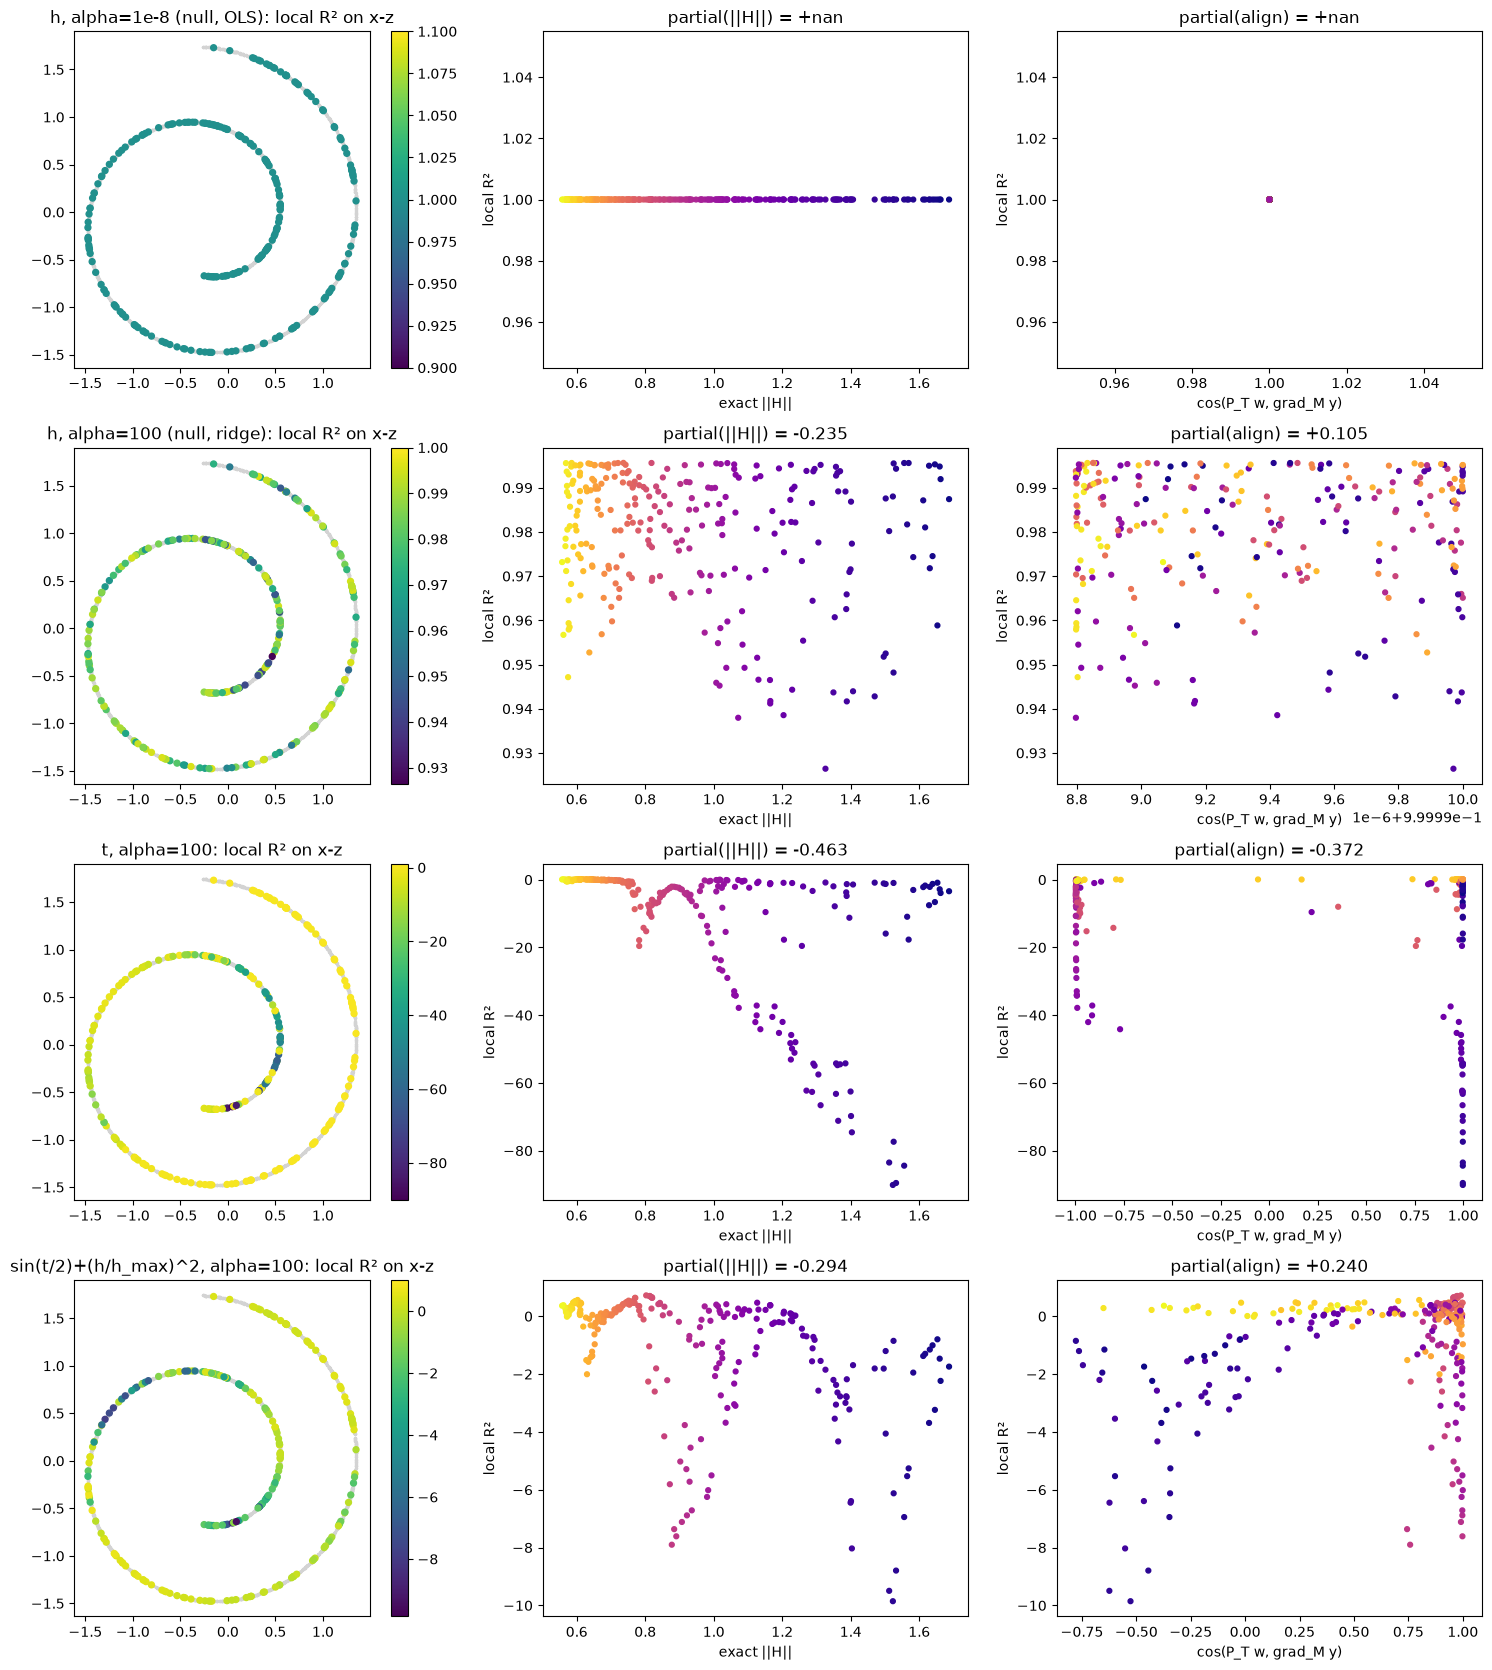

In [5]:
fig, axes = plt.subplots(len(results), 3, figsize=(15, 4.2 * len(results)))
for row, r in zip(axes, results):
    a = anchor_idx
    sc = row[0].scatter(X[a, 0], X[a, 2], c=r["r2"], cmap="viridis", s=18, vmin=np.nanmin(r["r2"]), vmax=1.0)
    row[0].scatter(X[:, 0], X[:, 2], c="lightgrey", s=2, zorder=0)
    row[0].set_title(f"{r['name']}: local R² on x-z"); row[0].set_aspect("equal"); plt.colorbar(sc, ax=row[0])
    row[1].scatter(H_true[a], r["r2"], s=12, c=t[a], cmap="plasma")
    row[1].set_xlabel("exact ||H||"); row[1].set_ylabel("local R²")
    row[1].set_title(f"partial(||H||) = {r['stat_H']['partial']:+.3f}")
    row[2].scatter(r["align"], r["r2"], s=12, c=t[a], cmap="plasma")
    row[2].set_xlabel("cos(P_T w, grad_M y)"); row[2].set_ylabel("local R²")
    row[2].set_title(f"partial(align) = {r['stat_align']['partial']:+.3f}")
plt.tight_layout(); plt.show()

## §6. Read-out

Pass/fail only where a value is known in advance. The `y = t` sign, the ridge-null partial and
the `||H||`-versus-alignment comparison are findings, not tests. For `y = t` the alignment cosine
is ±1 only: the label gradient and the probe's tangential component both lie along `e_t`, so that
column is a sign, not a continuous variable, and only the nonlinear arm gives it a real range.

In [6]:
ols, ridge_null, lin, nonlin = results
lines = [
    ("OLS null arm: partial(||H||) undefined (local R² has no variance) or |partial| < 0.10 with p > 0.05",
     ols["stat_H"]["undefined"] or (abs(ols["stat_H"]["partial"]) < 0.10 and ols["stat_H"]["p"] > 0.05)),
    ("OLS null arm: local R² > 0.999 at every anchor", bool(np.nanmin(ols["r2"]) > 0.999)),
    ("t arm: global probe fails somewhere (local R² p05 < 0.5)", bool(np.nanpercentile(lin["r2"], 5) < 0.5)),
]
for text, ok in lines:
    print(f"{'PASS' if ok else 'FAIL'}  {text}")
if ols["stat_H"]["undefined"]:
    print(f"      (OLS null: local R² min = {np.nanmin(ols['r2']):.6f}; sealed partial refused: {ols['stat_H']['reason'][:80]})")
sign = "NEGATIVE" if lin["stat_H"]["partial"] < 0 else "POSITIVE"
print(f"\nRidge null (y = h, alpha = 100): local R² p05/p50 = {np.nanpercentile(ridge_null['r2'], 5):.3f}/"
      f"{np.nanpercentile(ridge_null['r2'], 50):.3f}, controlled partial of ||H|| = {ridge_null['stat_H']['partial']:+.3f} "
      f"(p = {ridge_null['stat_H']['p']:.4f}): shrinkage alone, on an exactly linear label, produces a "
      f"curvature-correlated local R² that the three controls do not remove.")
print(f"On the Swiss roll with y = t, the controlled partial of exact ||H|| against local R² is "
      f"{sign} ({lin['stat_H']['partial']:+.3f}, p = {lin['stat_H']['p']:.4f}); the alignment column gives "
      f"{lin['stat_align']['partial']:+.3f} (p = {lin['stat_align']['p']:.4f}); the nonlinear arm gives "
      f"{nonlin['stat_H']['partial']:+.3f} for ||H|| and {nonlin['stat_align']['partial']:+.3f} for alignment.")

PASS  OLS null arm: partial(||H||) undefined (local R² has no variance) or |partial| < 0.10 with p > 0.05
PASS  OLS null arm: local R² > 0.999 at every anchor
PASS  t arm: global probe fails somewhere (local R² p05 < 0.5)
      (OLS null: local R² min = 1.000000; sealed partial refused: A control set that explains all variance in x or y leaves no residual to correla)

Ridge null (y = h, alpha = 100): local R² p05/p50 = 0.947/0.984, controlled partial of ||H|| = -0.235 (p = 0.0004): shrinkage alone, on an exactly linear label, produces a curvature-correlated local R² that the three controls do not remove.
On the Swiss roll with y = t, the controlled partial of exact ||H|| against local R² is NEGATIVE (-0.463, p = 0.0002); the alignment column gives -0.372 (p = 0.0002); the nonlinear arm gives -0.294 for ||H|| and +0.240 for alignment.
